<a href="https://colab.research.google.com/github/mjss26/EMSC2020-Individual-Project_MJSS/blob/main/EMSC2010_Individual_Project_MJSS_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Individual Project:**
## **How do environmental conditions influence observed moth activity in transect surveys, and what uncertainty is associated with these observations?**

## **Project Overview**

EMSC2010 Assessment 3

Name: **MJ Spencer-Stewart, u7121128**

Project title: How do environmental conditions influence observed moth activity in transect surveys, and what uncertainty is associated with these observations?

Datasets used (name and source):
- GSM Transect data collected Nov/Dec from 3 Canberra locations (collected for Fenner PhD research; no URL available - data from Excel file)
- BoM weather data (Bureau of Meteorology) - metadata available in excel sheet 'METADATA'

# **Acknowledgement of Country**
I acknowledge and pay my respects to the Ngunnawal and Ngambri peoples, the Traditional Custodians of the land on which this data collection took place. I recognise their continuing connection to land, waters, and culture, and pay my respects to Elders past and present.

## **Table of Contents**

1.  Introduction
2.  Analytical Approach
3.  Exploratory Data Analysis (EDA)
    *   Overview (Scatterplots - **Figure 1**)
    *   Correlation Analysis (**Table 1**, **Figure 2**)
    *   Grouped Hour Comparison (**Figure 3**)
4.  Basic Regression Results: Primary Environmental Variables
    *   Simple Linear Regression Results (**Table 2**)
    *   Bootstrap Distribution of Regression Slopes for Environmental Variables (**Figure 4**)
5.  Further Analysis - Does lagged maximum temperature analysis affect moth count
    *   Visualising the relationship between 'moth_count' and lagged maximum temperature features (**Figure 5**)
    *   Refactored Simple Linear Regression for Lagged Temperatures (**Table 3**)
    *   Refactored Bootstrap Regression for Lagged Temperatures (**Table 4**)
6.  Negative Binomial Regression for Lagged Temperatures
    *   Negative Binomial Regression Analysis (**Table 5**, **Table 6**)
7.  Monte Carlo Simulations for Detection Uncertainty
    *   Scenario 1: Constant Missed Detection Rate (20%) (**Figure 6**)
    *   Scenario 2: Conditional Missed Detection Rate (Temperature-Dependent) (**Figure 7**)
8.  Synthesised Findings and Conclusion
9.  Personal Reflection

# **Introduction**

## **Golden Sun Moth: An Overview**
The **Golden Sun Moth** (*Synemon plana*) is a threatened moth species endemic to south-eastern Australia, primarily found in remnant native grassland ecosystems in the ACT, NSW, and Victoria. These grasslands have undergone extensive clearing and fragmentation due to urban development and agriculture, resulting in highly patchy and vulnerable GSM populations. The Golden Sun Moth is listed as **Critically Endangered under national conservation frameworks**, reflecting its restricted distribution and ongoing habitat loss.

## **Challenges in Monitoring**
Monitoring GSM populations is challenging due to the species’ short adult lifespan and highly specific activity requirements. Adult moths are only active for brief periods under favourable environmental conditions, typically warm, sunny, and low-wind conditions. As a result, field surveys rely on transect-based observations, where observers walk fixed paths and record moth sightings alongside environmental variables such as temperature, wind, and cloud cover. The dataset used in this project was collected during field surveys conducted in collaboration with a PhD student from the Fenner School of Environment and Society, providing a real-world example of ecological monitoring practice. However, these surveys are subject to uncertainty, as a lack of observed moths does not necessarily indicate true absence, but may instead reflect unfavourable conditions for activity or detection.


## **Project Rationale and Aim**
Understanding how environmental conditions influence observed Golden Sun Moth activity is critical for interpreting field survey data and improving conservation monitoring. However, observational datasets inherently contain uncertainty, particularly where detections depend on both environmental conditions and observer effectiveness. This study therefore aims not only to identify potential environmental drivers of moth activity, but also to critically evaluate the uncertainty associated with these observations.

---

## **Aim**
In this notebook, I will use skills developed in the course to investigate how environmental variables influence observed activity of the Golden Sun Moth. In particular, I will explore how temperature, wind, cloud cover, and time of day affect the number of moths recorded during transect surveys.

This analysis will also consider the uncertainty inherent in field-based observations, where absence of sightings does not necessarily imply absence of the species.

I will demonstrate the following techniques:

Regression (modelling relationships between environmental variables and moth activity), Correlation (identifying associations between variables), and Data Visualisation (exploring patterns and variability in the dataset).

---

## **Data and Methods**
### **Dataset 1: Golden Sun Moth Transect Survey Data**

**Source:** Field data collected during surveys conducted in collaboration with a PhD student (Fenner School of Environment and Society)

**Description:** Observational dataset including moth sightings (counts of individuals) recorded alongside environmental conditions such as temperature, wind, cloud cover, and time of day

### **Dataset 2: Bureau of Meteorology (BoM) Data**

**Source:** Bureau of Meteorology

**Description:** Supplementary weather data used to derive maximum daily temperatures for the study region. These data were used to calculate the maximum temperature for the three days prior to each transect survey observation, enabling investigation of lagged temperature effects on moth activity.

**Metadata:** Additional information describing the BoM dataset (e.g. station details and data structure) is provided in the ‘metadata’ sheet within the Excel workbook.

### **Data Cleaning and Pre-processing**
To investigate the research questions, the datasets were compiled and cleaned to produce a structured dataset suitable for analysis. Data cleaning involved standardising missing values, removing incomplete entries, and converting categorical variables (e.g. wind and cloud cover) into numeric formats.

BoM temperature data were aligned with transect survey dates to calculate lagged maximum temperature variables (1-day, 2-day, and 3-day prior), as well as a mean prior maximum temperature. These derived variables were included to better reflect short-term environmental conditions relevant to the species’ life cycle.

The dataset reflects real-world field conditions and includes inconsistencies, missing values, and observer variability, all of which were explicitly considered during analysis and interpretation.

---

### **Research Questions**

1. How do environmental variables (temperature, wind, cloud cover, and time of day) influence observed Golden Sun Moth activity?

2. Which environmental conditions are most strongly associated with higher levels of moth activity?

3. To what extent can observed patterns be explained by environmental conditions, given the uncertainty associated with field survey data?

4. What limitations and sources of uncertainty must be considered when interpreting transect-based observations of GSM activity?

---

## **Resources**

Walker-Stelling, M. (2025). Golden sun moth [Poster]. Ginninderry. https://ginninderry.com/wp-content/uploads/2025/01/Maisie-Walker-Stelling-Golden-Sun-Moth-PosterCOMPRESSED.pdf

Richter, A., Osborne, W., Hnatiuk, S. et al. Moths in fragments: insights into the biology and ecology of the Australian endangered golden sun moth Synemon plana (Lepidoptera: Castniidae) in natural temperate and exotic grassland remnants. J Insect Conserv 17, 1093–1104 (2013). https://doi.org/10.1007/s10841-013-9589-1

Ginninderry. (2025, January 23). Identifying methods for translocation of the Golden Sun Moth in the reserves of the ACT. https://ginninderry.com/research-hub/identifying-methods-for-translocation-of-the-golden-sun-moth-in-the-reserves-of-the-act/ [ginninderry.com]

Context re species for Dave if interested: Trust for Nature. (2025). Golden sun moth (Synemon plana) [Brochure]. https://trustfornature.org.au/wp-content/uploads/2025/02/Golden-Sun-Moth-brochure.pdf

---

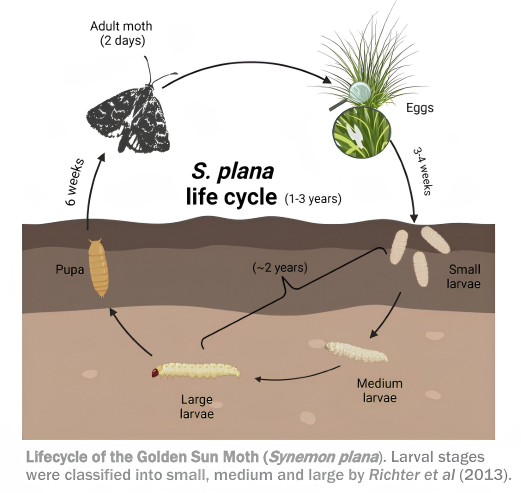

In [85]:
import numpy as np # For numerical operations, especially with arrays.
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations.
import pandas as pd # For data manipulation and analysis, especially with DataFrames.
import seaborn as sns # For making statistical graphics based on matplotlib.
import arviz as az # For exploratory analysis of Bayesian models.
from scipy.stats import linregress # For performing simple linear regression.
import statsmodels.formula.api as smf # For defining statistical models using formulas.
import statsmodels.api as sm # For fitting various statistical models.

In [86]:
# Apply a global seaborn theme for consistent aesthetics.
sns.set_theme(style="whitegrid", palette="viridis")

## **Transect field data - collected Nov/Dec 2025**

Upload the project data file 'moth_transects.xlsx' and use pandas to read in the first datasheet containing cleaned field data.

Extensive cleaning was completed in Excel prior to analysis. **Notes on all data cleaning steps can be found in the 'Cleaning notes' sheet in the Excel file.**

The following cells:
* Read in the datasheet and create a DataFrame
* Display the first few rows of the DataFrame

In [87]:
# Load the dataset from an Excel file named 'moth_transects.xlsx'.
# The data is specifically taken from the sheet named 'transect_data'.
df = pd.read_excel("moth_transects.xlsx", sheet_name='transect_data')

# Display the first few rows of the DataFrame to get an overview of the data structure.
df.head()

,Obs ID,Date,Reserve,Site,Transect,Segment,site_id,Time Start,Time End,time_of_day,...,OTHER SPECIES,Other species count,insect_richness,Transect - Males,Transect - Felmales,moth_count,NOTES,Column4,Column5,Column6
0,ID_1,2025-11-03,G,1,1,1,ID_1-G-1-1-1,10:43:00,10:53:00,10.716667,...,"Checkered Copper, White moth",2,7,0,0,0,NaN,NaN,NaN,NaN
1,ID_2,2025-11-03,G,1,1,1,ID_2-G-1-1-1,10:43:00,10:53:00,10.716667,...,"Fly, Blue forester, Bee, Checkered Copper, Whi...",5,8,0,0,0,Early iteration of data sheet without species ...,NaN,NaN,NaN
2,ID_3,2025-11-03,G,1,2,1,ID_3-G-1-2-1,10:59:00,11:10:00,10.983333,...,"Beetles (?), Checkered Copper",2,6,0,0,0,Early iteration of data sheet without species ...,NaN,NaN,NaN
3,ID_4,2025-11-03,G,1,2,1,ID_4-G-1-2-1,10:59:00,11:10:00,10.983333,...,NaN,0,3,0,0,0,NaN,NaN,NaN,NaN
4,ID_5,2025-11-03,G,1,3,1,ID_5-G-1-3-1,11:13:00,11:24:00,11.216667,...,"Fly, Brown moth, Bee",3,6,0,0,0,Early iteration of data sheet without species ...,NaN,NaN,NaN


## **Analytical Approach**

To investigate how environmental conditions influence observed Golden Sun Moth activity, this analysis follows a structured workflow:

1. **Exploratory Data Analysis (EDA)** – to identify patterns, variability, and potential relationships between environmental variables and moth counts.
2. **Correlation and Linear Regression** – to quantify linear relationships between moth activity and environmental variables.
3. **Bootstrap Analysis** – to assess uncertainty in regression estimates and determine whether observed relationships are robust.
4. **Lagged Temperature Analysis** – to test whether prior environmental conditions influence observed moth activity, reflecting the species’ short adult lifespan.
5. **Generalised Linear Models (Negative Binomial)** – to account for the count-based nature of moth data and potential overdispersion.
6. **Uncertainty Modelling (Monte Carlo Simulations)** – to assess how imperfect detection influences observed relationships.

This combination of methods allows both identification of patterns and explicit quantification of uncertainty, which is critical when interpreting ecological field data.

## **Exploratory Data Analysis (EDA)**

### **Overview**
This section explores patterns in moth counts across key environmental variables. Scatter plots are used to visually assess relationships, and a correlation matrix is used to quantify the strength of linear associations between variables.

Exploratory data analysis was used as a first step to understand the structure and variability of the dataset before applying statistical tests. Because this is real field data, I expected substantial variability and wanted to visually assess whether any clear patterns existed.

Scatter plots were particularly useful for identifying whether relationships might be linear, non-linear, or absent altogether, which helped guide the choice of later analyses.

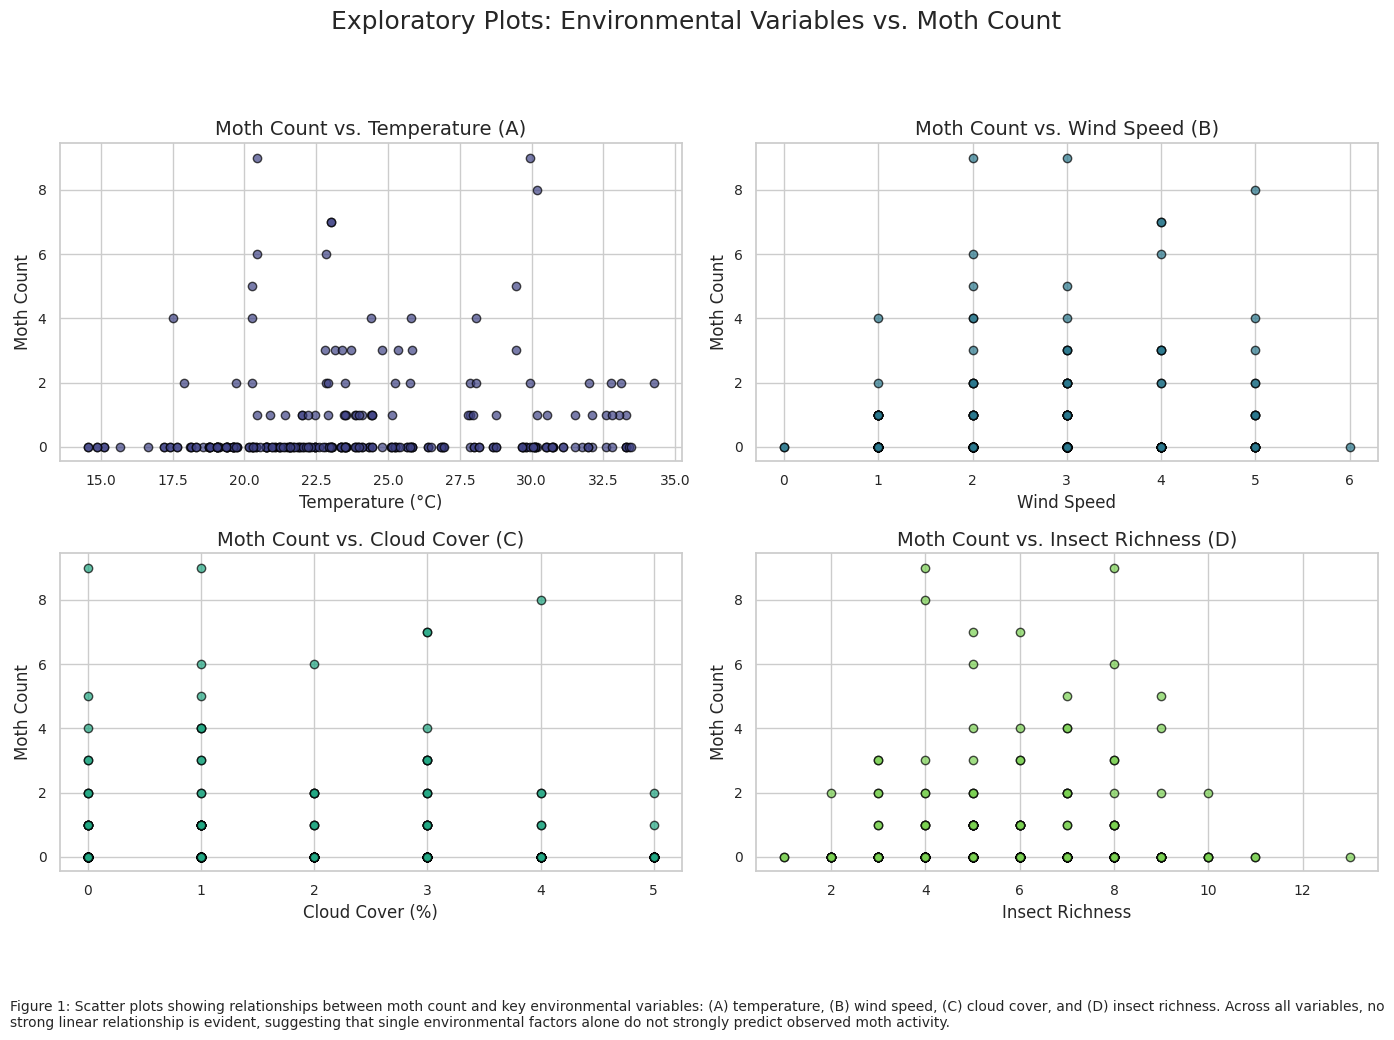

In [88]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
axes = ax.flatten()

variables = ['temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']
colors = sns.color_palette("viridis", n_colors=len(variables))

axes[0].scatter(df['temp_avg'], df['moth_count'], color=colors[0], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Moth Count', fontsize=12)
axes[0].set_title('Moth Count vs. Temperature (A)', fontsize=14)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)

axes[1].scatter(df['wind_speed'], df['moth_count'], color=colors[1], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Wind Speed', fontsize=12)
axes[1].set_ylabel('Moth Count', fontsize=12)
axes[1].set_title('Moth Count vs. Wind Speed (B)', fontsize=14)
axes[1].tick_params(axis='x', labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

axes[2].scatter(df['cloud_cover'], df['moth_count'], color=colors[2], alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Cloud Cover (%)', fontsize=12)
axes[2].set_ylabel('Moth Count', fontsize=12)
axes[2].set_title('Moth Count vs. Cloud Cover (C)', fontsize=14)
axes[2].tick_params(axis='x', labelsize=10)
axes[2].tick_params(axis='y', labelsize=10)

axes[3].scatter(df['insect_richness'], df['moth_count'], color=colors[3], alpha=0.7, edgecolor='black')
axes[3].set_xlabel('Insect Richness', fontsize=12)
axes[3].set_ylabel('Moth Count', fontsize=12)
axes[3].set_title('Moth Count vs. Insect Richness (D)', fontsize=14)
axes[3].tick_params(axis='x', labelsize=10)
axes[3].tick_params(axis='y', labelsize=10)

fig.suptitle('Exploratory Plots: Environmental Variables vs. Moth Count', fontsize=18, y=1.03)

caption_text_1 = "Figure 1: Scatter plots showing relationships between moth count and key environmental variables: (A) temperature, (B) wind speed, (C) cloud cover, and (D) insect richness. Across all variables, no strong linear relationship is evident, suggesting that single environmental factors alone do not strongly predict observed moth activity."
plt.figtext(0.01, 0.01, caption_text_1, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.98])
plt.show()

**Figure 1** shows no clear linear relationship between moth count and the examined environmental variables. While slight positive trends may be visible for temperature and wind speed, the high variability across similar conditions suggests these variables alone are not strong predictors of observed activity, and may reflect behavioural responses, microclimatic variation, or inconsistencies in detection during surveys.

## **Correlation Analysis**

**Table 1** and **Figure 2**: The correlation matrix and its heatmap visualization display the pairwise correlation coefficients between moth count and key environmental variables (temperature, wind speed, cloud cover, and insect richness).

Correlation analysis was used as a simple way to quantify linear relationships between variables and provide a baseline understanding before applying more complex models.

I chose this method because it allowed me to quickly assess whether any variables showed clear relationships before moving on to more complex models.

In [89]:
# Calculate the correlation matrix for selected variables.
# This helps to understand the linear relationships between moth count and environmental factors.
corr = df[['moth_count', 'temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']].corr()

# Display the correlation matrix as Table 1
print("Table 1: Correlation Matrix of Environmental Variables and Moth Count")
display(corr.style.format(formatter='{:.2f}').set_table_attributes('style="display:inline"'))

Table 1: Correlation Matrix of Environmental Variables and Moth Count


,moth_count,temp_avg,wind_speed,cloud_cover,insect_richness
moth_count,1.00,0.10,0.15,-0.04,0.02
temp_avg,0.10,1.00,0.20,0.00,-0.26
wind_speed,0.15,0.20,1.00,0.22,-0.13
cloud_cover,-0.04,0.00,0.22,1.00,-0.20
insect_richness,0.02,-0.26,-0.13,-0.20,1.00


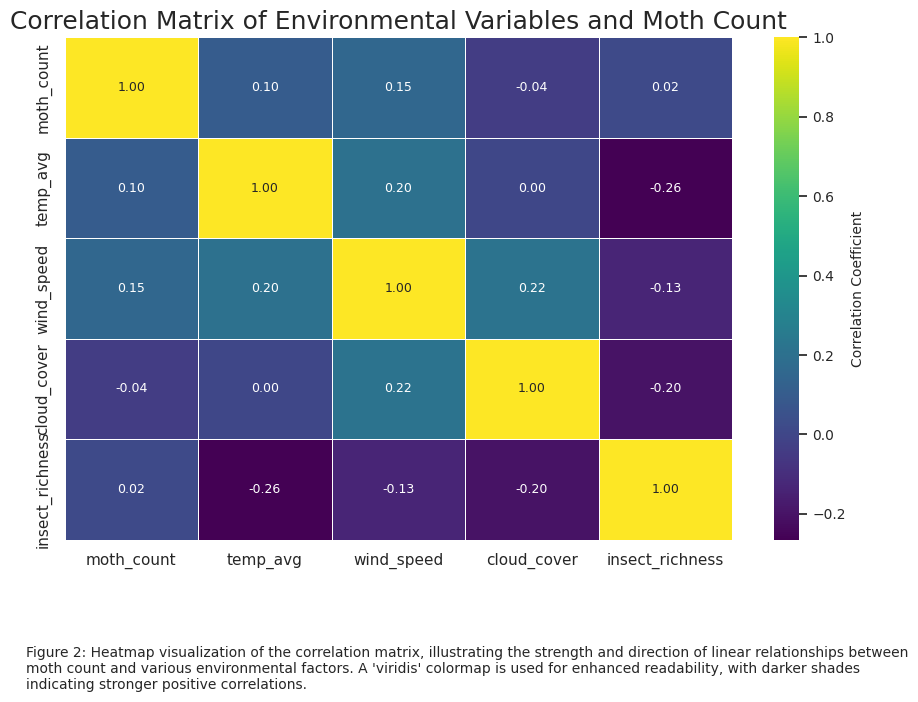

In [90]:
# Display the correlation matrix as a heatmap for better visualization of relationships.
plt.figure(figsize=(9, 7))
ax = sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f", linewidths=.7, linecolor='white', cbar_kws={'label': 'Correlation Coefficient'}, annot_kws={
        "fontsize": 9
    })
cb = ax.collections[0].colorbar # Get the colorbar object
cb.set_label('Correlation Coefficient', fontsize=10) # Set colorbar label fontsize
cb.ax.tick_params(labelsize=10) # Set colorbar tick labels fontsize

plt.title("Correlation Matrix of Environmental Variables and Moth Count", fontsize=18)

caption_text_2 = "Figure 2: Heatmap visualization of the correlation matrix, illustrating the strength and direction of linear relationships between moth count and various environmental factors. A 'viridis' colormap is used for enhanced readability, with darker shades indicating stronger positive correlations."
plt.figtext(0.01, -0.05, caption_text_2, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

The correlation matrix (**Figure 2**) shows generally weak relationships between moth count and all environmental variables, with correlation coefficients close to zero.

This suggests that linear relationships between individual environmental variables and moth activity are weak. This may reflect the influence of multiple interacting factors, as well as variability in detection during field surveys.

### **Grouped Hour Comparison (**Figure 3**)**

This section analyzes moth activity patterns based on the time of day, providing initial insights into potential diurnal variations that may influence observations.

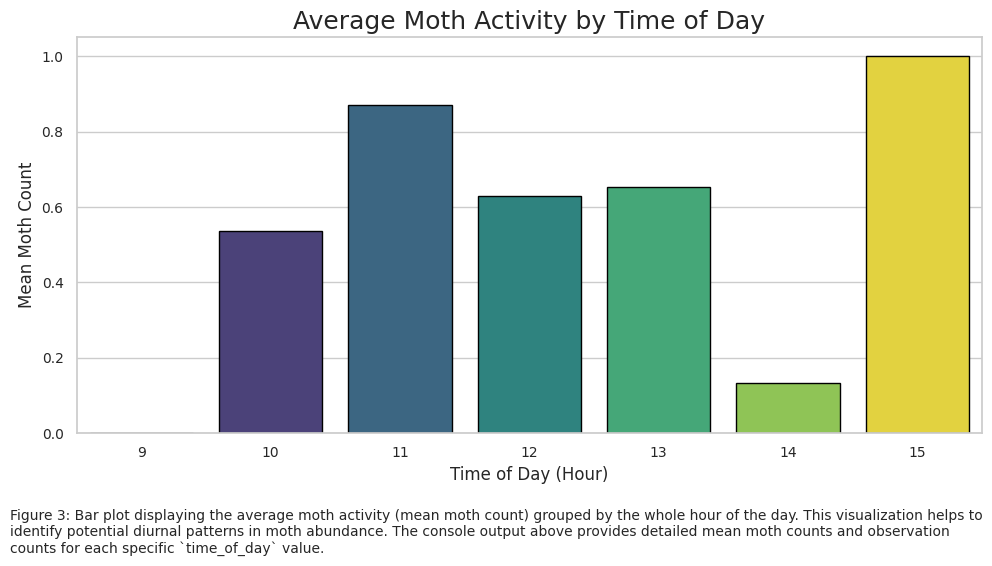

In [91]:
# GROUP COMPARISON (basic summary of moth activity by time of day)

plot_groups = df.groupby(df['time_of_day'].astype(int))['moth_count'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=plot_groups.index, y=plot_groups.values, ax=ax, palette="viridis", hue=plot_groups.index, legend=False, edgecolor='black')

ax.set_ylabel('Mean Moth Count', fontsize=12)
ax.set_xlabel('Time of Day (Hour)', fontsize=12)
ax.set_title('Average Moth Activity by Time of Day', fontsize=18)
ax.set_xticks(range(len(plot_groups.index)))
ax.set_xticklabels(plot_groups.index, rotation=0, fontsize=10)
ax.tick_params(axis='y', labelsize=10)

caption_text_4 = "Figure 3: Bar plot displaying the average moth activity (mean moth count) grouped by the whole hour of the day. This visualization helps to identify potential diurnal patterns in moth abundance. The console output above provides detailed mean moth counts and observation counts for each specific `time_of_day` value."
plt.figtext(0.01, 0.01, caption_text_4, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

**Figure 3** suggests that moth activity does not vary strongly across hours of the day within the sampled period. While small fluctuations are visible, these differences are inconsistent, indicating that time of day alone is unlikely to be a dominant driver of observed activity within the survey window. This may reflect that surveys were conducted within a relatively narrow period of suitable conditions for moth activity.

Simple linear regression was used as an initial approach to quantify relationships between environmental variables and moth count. While ecological relationships are often non-linear, linear models provide a useful baseline for identifying trends and testing whether clear directional effects exist.


## **Basic Regression Results: Primary Environmental Variables**

This section presents the initial regression analyses for the primary environmental variables (`temp_avg`, `wind_speed`, `cloud_cover`, `insect_richness`) against moth count. It includes simple linear regression results and bootstrap regression distributions to understand the linear relationships and their uncertainties.

## **Simple Linear Regression Results**

**Table 2**: This table displays the results of simple linear regressions, showing the regression coefficient and R-squared values for the relationship between moth count and individual environmental variables.

Linear regression was used as an initial modelling approach because it provides a straightforward way to test for relationships between environmental variables and moth count. Although I was aware that ecological relationships are often non-linear, I chose this method as a starting point to determine whether any clear directional trends existed, consistent with the techniques covered in the course.

In [92]:
# Define the environmental variables for which to perform simple linear regression.
variables = ['temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']

results = {} # Initialize an empty dictionary to store regression results.

# Loop through each environmental variable to perform simple linear regression.
for var in variables:
    # Perform linear regression using scipy.stats.linregress.
    # It returns the slope (regression_coefficient), intercept, r-value, p-value, and standard error.
    regression_coefficient, intercept, r, p, se = linregress(df[var], df['moth_count'])
    # Store the regression coefficient and R-squared value (r**2) in the results dictionary.
    results[var] = {'regression_coefficient': regression_coefficient, 'r2': r**2}

# Convert the results dictionary to a pandas DataFrame for a clean tabular display.
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'Variable' # Name the index column 'Variable'.

# Display the DataFrame with enhanced styling as Table 2
print("Table 2: Simple Linear Regression Results")
display(results_df.style.format(formatter='{:.3f}').set_table_attributes('style="display:inline"'))

Table 2: Simple Linear Regression Results


,regression_coefficient,r2
Variable,,
temp_avg,0.031,0.009
wind_speed,0.201,0.024
cloud_cover,-0.035,0.002
insect_richness,0.013,0.000



The regression results (**Table 2**) show consistently low R² values across all variables, indicating that individual environmental factors explain very little variation in moth count. This supports the patterns observed in **Figure 1** and suggests that moth activity is not strongly driven by any single environmental variable when considered in isolation.

temp_avg CI: [-0.00346463  0.06843991]
wind_speed CI: [0.04535256 0.38062845]
cloud_cover CI: [-0.12507655  0.05805621]
insect_richness CI: [-0.06545293  0.09562357]


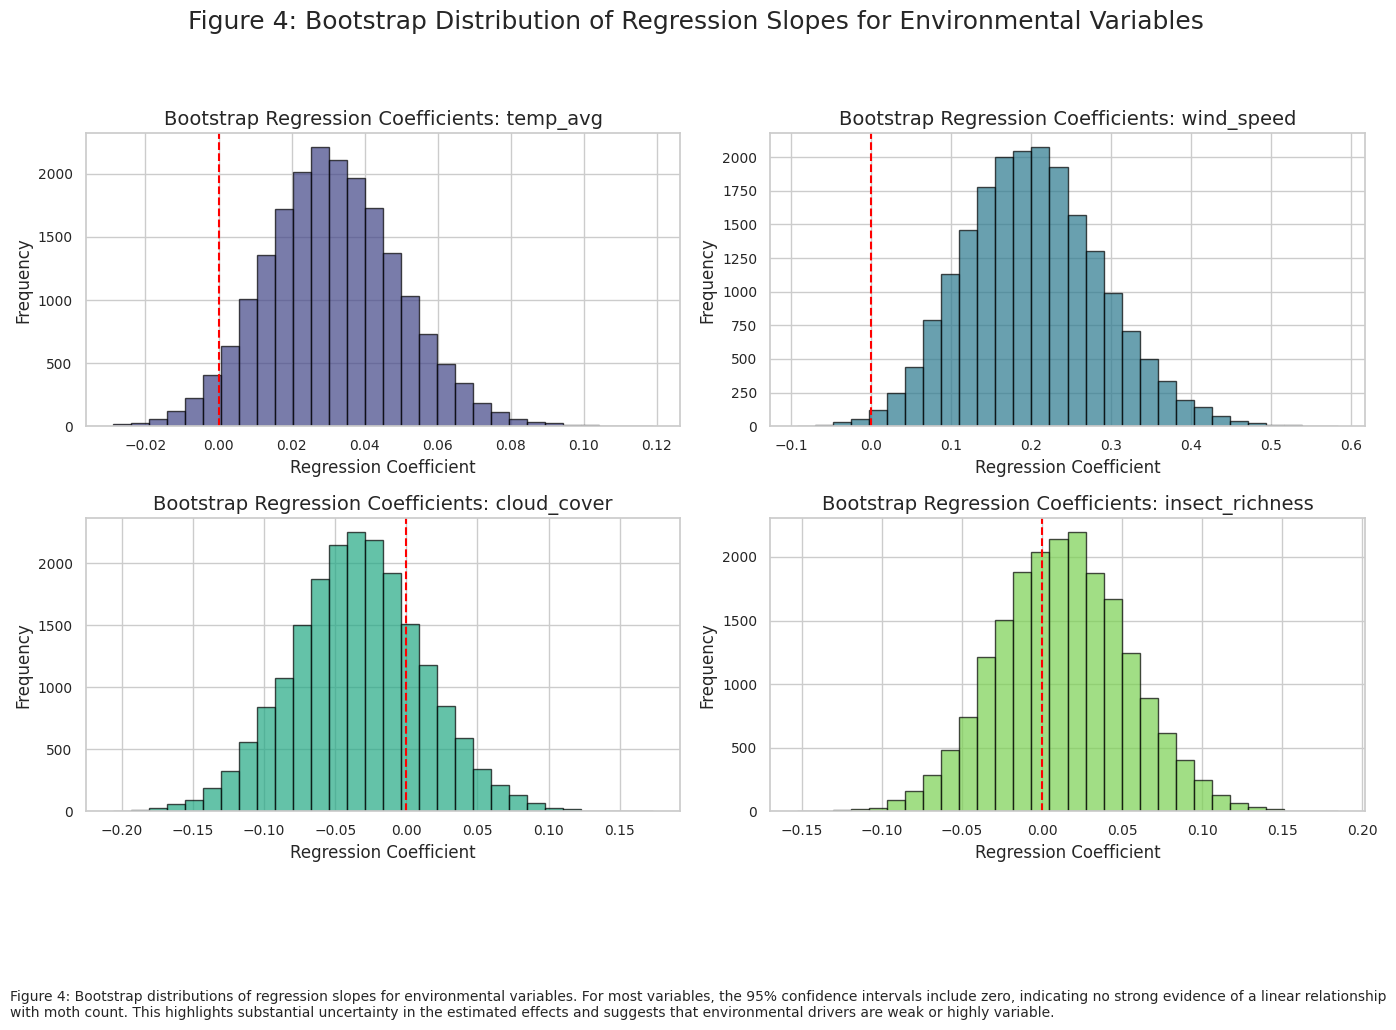

In [93]:
# Initialize a dictionary to store bootstrap results for each variable.
bootstrap_results = {}

# Create a single figure with a 2x2 grid of subplots.
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Increased figure size for better readability
axes = axes.flatten()

# Define the variables for which to perform bootstrapping.
variables = ['temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']
colors = sns.color_palette("viridis", n_colors=len(variables)) # Use the 'viridis' color palette for consistency

# Loop through each variable and its corresponding subplot index.
for i, var in enumerate(variables):
    slopes = []

    # Perform 20,000 bootstrap samples.
    for _ in range(20000):
        sample = df.sample(frac=1, replace=True)
        regression_coefficient, _, _, _, _ = linregress(sample[var], sample['moth_count'])
        slopes.append(regression_coefficient)

    bootstrap_results[var] = slopes

    axes[i].hist(slopes, bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Bootstrap Regression Coefficients: {var}', fontsize=14)
    axes[i].set_xlabel('Regression Coefficient', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

    ci = np.percentile(slopes, [2.5, 97.5])
    print(f"{var} CI: {ci}")

fig.suptitle('Figure 4: Bootstrap Distribution of Regression Slopes for Environmental Variables', fontsize=18, y=1.02)

caption_text_3 = "Figure 4: Bootstrap distributions of regression slopes for environmental variables. For most variables, the 95% confidence intervals include zero, indicating no strong evidence of a linear relationship with moth count. This highlights substantial uncertainty in the estimated effects and suggests that environmental drivers are weak or highly variable."
plt.figtext(0.01, 0.01, caption_text_3, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.15, 1, 0.98])
plt.show()


The bootstrap results (**Figure 4**) reinforce this uncertainty. For most variables, the confidence intervals for regression slopes include zero, indicating that estimated relationships are not statistically robust. This indicates that observed trends are highly sensitive to sampling variability and may not represent consistent underlying ecological effects.

Bootstrapping was used to assess uncertainty in the regression results. While linear regression provides a single estimate, bootstrapping repeatedly resamples the data to show how stable those estimates are, giving a clearer picture of uncertainty, showing how sensitive these results were to sampling variability.

## **Further Analysis - Does lagged maximum temperature analysis affect moth count?**

### **Rationale for Lagged Temperature Variables**
Maximum daily temperature for the study region was obtained from the Bureau of Meteorology (BoM) for the three days preceding each transect observation. This time window was selected based on the short adult lifespan of Golden Sun Moths (approximately 1–3 days), representing the maximum period over which prior environmental conditions may influence observed activity.

This analysis aims to explore whether elevated maximum temperatures in the days prior to observation are associated with increased moth counts, potentially reflecting emergence events or periods of heightened activity. While this approach cannot definitively determine causation, it provides insight into the temporal relationship between maximum temperature and moth activity.

### **Implications for Conservation**
Understanding these patterns may be useful for informing future survey and conservation efforts, particularly by identifying environmental conditions under which GSM are most likely to emerge and be active. This could help refine the timing of monitoring or trapping strategies aimed at supporting breeding efforts.

### **Variable Definition: Mean Prior Maximum Temperature**
In addition to incorporating the three preceding maximum temperature values as separate variables, a new variable representing the mean of the three prior maximum temperatures was also calculated. This provides a smoothed measure of recent thermal conditions, allowing comparison between short-term variability and overall temperature trends in the days leading up to observed moth activity.

Lagged temperature variables were included because of the biology of the Golden Sun Moth, which has a very short adult lifespan. I expected that environmental conditions in the days prior to observation could influence emergence and activity. This approach allowed me to test whether recent temperature history, rather than just conditions at the time of survey, might better explain variation in moth counts.

### **Visualising the relationship between 'moth_count' and lagged maximum temperature features (**Figure 5**).**

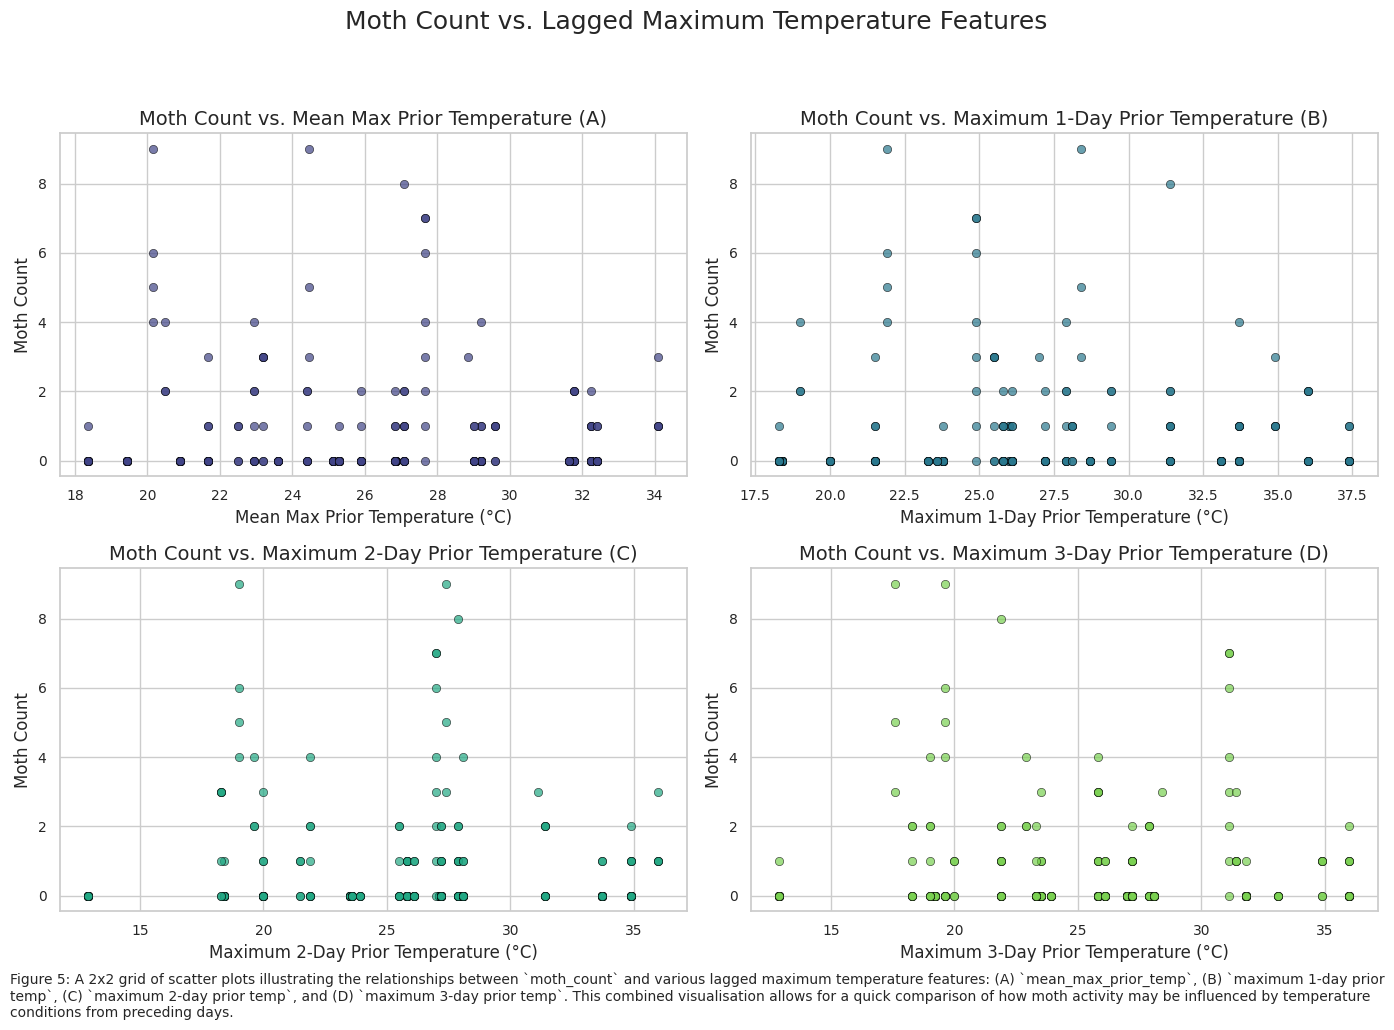

In [94]:
# Set theme and use a distinct color palette

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
axes = ax.flatten()

lagged_temp_vars = [
    ('mean_max_prior_temp', 'Mean Max Prior Temperature (A)'),
    ('1_day_prior_temp', 'Maximum 1-Day Prior Temperature (B)'),
    ('2_day_prior_temp', 'Maximum 2-Day Prior Temperature (C)'),
    ('3_day_prior_temp', 'Maximum 3-Day Prior Temperature (D)')
]

colors = sns.color_palette("viridis", n_colors=len(lagged_temp_vars)) # Using the 'viridis' color palette for consistency

for i, (var, title) in enumerate(lagged_temp_vars):
    sns.scatterplot(data=df, x=var, y='moth_count', ax=axes[i], color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Moth Count vs. {title}', fontsize=14)
    axes[i].set_xlabel(f'{title.split(" (")[0]} (°C)', fontsize=12)
    axes[i].set_ylabel('Moth Count', fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

fig.suptitle('Moth Count vs. Lagged Maximum Temperature Features', fontsize=18, y=1.02)

caption_text_7 = "Figure 5: A 2x2 grid of scatter plots illustrating the relationships between `moth_count` and various lagged maximum temperature features: (A) `mean_max_prior_temp`, (B) `maximum 1-day prior temp`, (C) `maximum 2-day prior temp`, and (D) `maximum 3-day prior temp`. This combined visualisation allows for a quick comparison of how moth activity may be influenced by temperature conditions from preceding days."
plt.figtext(0.01, 0.01, caption_text_7, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


**Figure 5** shows no clear relationship between moth count and lagged temperature variables. The absence of consistent trends across all time lags suggests that prior temperature conditions, within the 1–3 day window examined, do not strongly influence observed moth activity in this dataset.

## **Revised Simple Linear Regression for Lagged Temperatures**

**Table 3**: This table presents the consolidated results of simple linear regression for moth count against each lagged temperature feature, including the slope, intercept, R-value (correlation coefficient), P-value, and standard error for each relationship, providing an initial assessment of linear associations.

In [95]:
lagged_temps = ['mean_max_prior_temp', '1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp']

print("### Simple Linear Regression Results for Lagged Temperatures ###")

all_slr_results = {}

for temp_col in lagged_temps:
    slope, intercept, r_value, p_value, std_err = linregress(df[temp_col], df['moth_count'])

    all_slr_results[temp_col] = {
        'Slope': slope,
        'Intercept': intercept,
        'R-value': r_value,
        'P-value': p_value,
        'Std. Error': std_err
    }

# Display the DataFrame with enhanced styling as Table 3
print("Table 3: Simple Linear Regression Results for Lagged Temperatures")
display(pd.DataFrame.from_dict(all_slr_results, orient='index').style.format(formatter='{:.4f}').set_table_attributes('style="display:inline"'))

### Simple Linear Regression Results for Lagged Temperatures ###
Table 3: Simple Linear Regression Results for Lagged Temperatures


,Slope,Intercept,R-value,P-value,Std. Error
mean_max_prior_temp,-0.0012,0.6505,-0.0038,0.9507,0.0201
1_day_prior_temp,0.0100,0.3556,0.0391,0.5224,0.0156
2_day_prior_temp,-0.0000,0.6190,-0.0001,0.9989,0.0153
3_day_prior_temp,-0.0120,0.9206,-0.0473,0.4387,0.0154


The regression results for lagged temperatures further confirm the absence of a strong relationship. Low R-values and non-significant p-values across all lagged variables indicate that prior temperature conditions do not strongly influence observed moth counts when considered independently within the dataset.

## **Revised Bootstrap Regression for Lagged Temperatures**

**Table 4**: This table displays the consolidated bootstrap regression results for moth count against each lagged temperature feature. It includes the mean slope and mean intercept, along with their respective 95% confidence intervals, derived from 1000 bootstrap samples. These results provide a robust measure of uncertainty around the regression coefficients.

In [96]:
lagged_temps = ['mean_max_prior_temp', '1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp']
n_bootstraps = 1000

print("### Bootstrap Regression Results for Lagged Temperatures ###")

all_bootstrap_results = {}

for temp_col in lagged_temps:
    bootstrap_slopes = []
    bootstrap_intercepts = []

    for _ in range(n_bootstraps):
        resampled_df = df.sample(n=len(df), replace=True)
        slope_b, intercept_b, _, _, _ = linregress(resampled_df[temp_col], resampled_df['moth_count'])
        bootstrap_slopes.append(slope_b)
        bootstrap_intercepts.append(intercept_b)

    lower_bound_slope = np.percentile(bootstrap_slopes, 2.5)
    upper_bound_slope = np.percentile(bootstrap_slopes, 97.5)
    lower_bound_intercept = np.percentile(bootstrap_intercepts, 2.5)
    upper_bound_intercept = np.percentile(bootstrap_intercepts, 97.5)

    print(f"\nBootstrap Regression for moth_count vs. {temp_col} (n={n_bootstraps} bootstraps):")
    print(f"  Mean Slope: {np.mean(bootstrap_slopes):.4f} (95% CI: [{lower_bound_slope:.4f}, {upper_bound_slope:.4f}])")
    print(f"  Mean Intercept: {np.mean(bootstrap_intercepts):.4f} (95% CI: [{lower_bound_intercept:.4f}, {upper_bound_intercept:.4f}])")

    all_bootstrap_results[temp_col] = {
        'Mean Slope': np.mean(bootstrap_slopes),
        '95% CI (Slope)': f"[{lower_bound_slope:.4f}, {upper_bound_slope:.4f}]",
        'Mean Intercept': np.mean(bootstrap_intercepts),
        '95% CI (Intercept)': f"[{lower_bound_intercept:.4f}, {upper_bound_intercept:.4f}]"
    }

# Display the DataFrame with enhanced styling as Table 4
print("Table 4: Bootstrap Regression Results for Lagged Temperatures")
display(pd.DataFrame.from_dict(all_bootstrap_results, orient='index').style.format({
    'Mean Slope': '{:.4f}',
    '95% CI (Slope)': '{}',
    'Mean Intercept': '{:.4f}',
    '95% CI (Intercept)': '{}'
}).set_table_attributes('style="display:inline"'))

### Bootstrap Regression Results for Lagged Temperatures ###

Bootstrap Regression for moth_count vs. mean_max_prior_temp (n=1000 bootstraps):
  Mean Slope: -0.0013 (95% CI: [-0.0360, 0.0299])
  Mean Intercept: 0.6512 (95% CI: [-0.1449, 1.6547])

Bootstrap Regression for moth_count vs. 1_day_prior_temp (n=1000 bootstraps):
  Mean Slope: 0.0098 (95% CI: [-0.0131, 0.0340])
  Mean Intercept: 0.3614 (95% CI: [-0.2810, 1.0337])

Bootstrap Regression for moth_count vs. 2_day_prior_temp (n=1000 bootstraps):
  Mean Slope: -0.0004 (95% CI: [-0.0250, 0.0210])
  Mean Intercept: 0.6237 (95% CI: [0.0685, 1.2684])

Bootstrap Regression for moth_count vs. 3_day_prior_temp (n=1000 bootstraps):
  Mean Slope: -0.0126 (95% CI: [-0.0439, 0.0164])
  Mean Intercept: 0.9421 (95% CI: [0.1655, 1.8095])
Table 4: Bootstrap Regression Results for Lagged Temperatures


,Mean Slope,95% CI (Slope),Mean Intercept,95% CI (Intercept)
mean_max_prior_temp,-0.0013,"[-0.0360, 0.0299]",0.6512,"[-0.1449, 1.6547]"
1_day_prior_temp,0.0098,"[-0.0131, 0.0340]",0.3614,"[-0.2810, 1.0337]"
2_day_prior_temp,-0.0004,"[-0.0250, 0.0210]",0.6237,"[0.0685, 1.2684]"
3_day_prior_temp,-0.0126,"[-0.0439, 0.0164]",0.9421,"[0.1655, 1.8095]"


## **Negative Binomial Regression for Lagged Temperatures**

### **Negative Binomial Regression Analysis**
This section performs Negative Binomial regression for 'moth_count' against each lagged temperature feature ('mean_max_prior_temp', '1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp'). This model is appropriate for count data that may exhibit overdispersion.

**Table 5**: This section presents the Negative Binomial regression summary for moth count against mean max prior temperature.

In [97]:
# Ensure moth_count is non-negative and integer type for Negative Binomial regression
df['moth_count'] = df['moth_count'].astype(int)

# Build the formula string
formula_mean_max = 'moth_count ~ mean_max_prior_temp'

# Fit the Negative Binomial model
nb_model_mean_max = smf.glm(formula=formula_mean_max, data=df, family=sm.families.NegativeBinomial())
nb_results_mean_max = nb_model_mean_max.fit()

print(f"\nNegative Binomial Regression for moth_count vs. mean_max_prior_temp:")
print(nb_results_mean_max.summary())


Negative Binomial Regression for moth_count vs. mean_max_prior_temp:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             moth_count   No. Observations:                  270
Model:                            GLM   Df Residuals:                      268
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -290.65
Date:                Tue, 02 Jun 2026   Deviance:                       323.41
Time:                        01:46:10   Pearson chi2:                     584.
No. Iterations:                     7   Pseudo R-squ. (CS):          3.406e-05
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


**Table 6**: This section presents the Negative Binomial regression summaries for moth count against 1-day, 2-day, and 3-day prior temperatures.

In [98]:
prior_day_temps = ['1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp']

for temp_col in prior_day_temps:
    print(f"\n{'='*80}")
    print(f"Negative Binomial Regression for moth_count vs. {temp_col}:")
    # The formula needs to handle column names that start with numbers by quoting them using Q() in patsy
    formula_individual = f'moth_count ~ Q("{temp_col}")'
    nb_model_individual = smf.glm(formula=formula_individual, data=df, family=sm.families.NegativeBinomial())
    nb_results_individual = nb_model_individual.fit()
    print(nb_results_individual.summary())


Negative Binomial Regression for moth_count vs. 1_day_prior_temp:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             moth_count   No. Observations:                  270
Model:                            GLM   Df Residuals:                      268
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -290.13
Date:                Tue, 02 Jun 2026   Deviance:                       322.37
Time:                        01:46:10   Pearson chi2:                     596.
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003884
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## **Negative Binomial Regression: Rationale and Results**

Although Negative Binomial regression was not covered in this course, I chose to use it after struggling to identify any clear relationships using the methods we had learned. I wanted to explore whether the lack of results was due to the data itself or the limitations of the models I was using.

Through further research, I found that Negative Binomial regression is commonly used for ecological count data like this, where values are discrete and highly variable. Moth counts often include many low values and occasional high counts, which violates the assumptions of linear regression. This model accounts for that variability by allowing for overdispersion, making it more appropriate for this type of data.

While it still did not produce strong relationships, including this model gave me more confidence that the results reflect real ecological complexity rather than just an inappropriate analytical approach.

The Negative Binomial regression results align with previous analyses, showing no significant relationship between lagged temperature variables and moth count. This indicates that even when accounting for the discrete and overdispersed nature of count data, temperature alone does not strongly predict observed activity.

## **Monte Carlo Simulations for Detection Uncertainty**

To understand the impact of imperfect detection on the analysis, I conducted Monte Carlo simulations. I'll explore two scenarios: a constant missed detection rate and a conditional (temperature-dependent) missed detection rate.

### **Why Monte Carlo Simulations?**
Monte Carlo simulation was used to explicitly explore uncertainty related to imperfect detection, which is a key limitation of field-based ecological data. I chose this approach because standard statistical models assume that observed counts reflect true abundance, which is unlikely in transect surveys.

By simulating missed detections under different scenarios (constant and temperature-dependent), I was able to assess how detection bias might influence the observed relationships.
This approach helped move beyond simply analysing patterns in the data, and instead allowed me to test how robust those patterns are under realistic ecological assumptions.

### **Scenario 1: Constant Missed Detection Rate (20%)**

Original linear regression slope (moth_count vs. temp_avg): 0.0312

Monte Carlo (Bootstrap) for moth_count vs. temp_avg with CONSTANT Missed Detection (20%):
  Mean Slope (adjusted): 0.0390 (95% CI: [-0.0009, 0.0829])


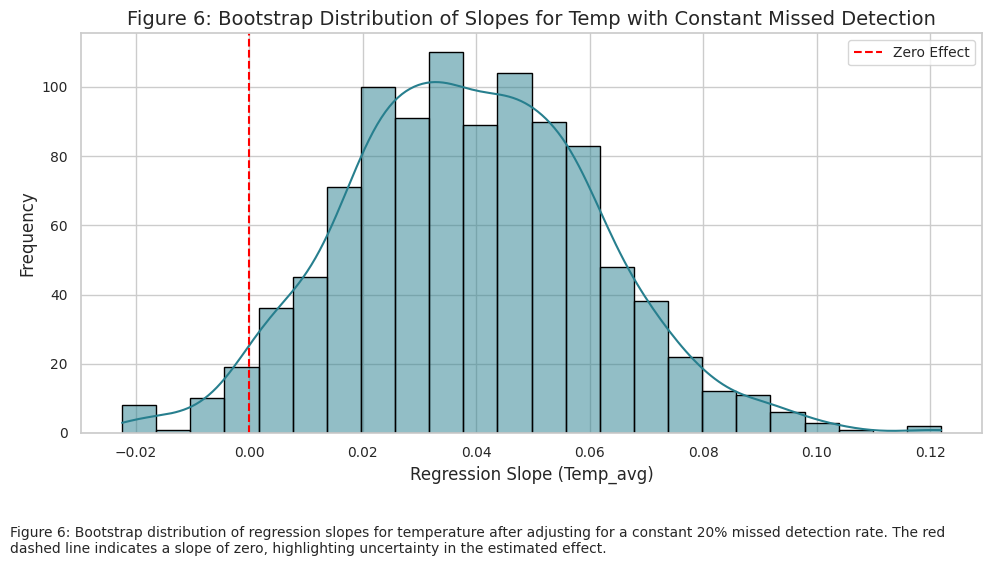

In [99]:
# Monte Carlo simulation: constant missed detection (20%)
n_simulations = 1000

missed_detection_rate_constant = 0.20

# Baseline relationship for reference
original_slope, _, _, _, _ = linregress(df['temp_avg'], df['moth_count'])
print(f"Original linear regression slope (moth_count vs. temp_avg): {original_slope:.4f}")

# Adjust counts to account for missed detections (observed = 80% of true)
adjusted_df = df.copy()
adjusted_df['moth_count_adjusted'] = adjusted_df['moth_count'] / (1 - missed_detection_rate_constant)

# Bootstrap regression on adjusted counts
boot_slopes_adjusted = []
for _ in range(n_simulations):
    resampled_adj_df = adjusted_df.sample(n=len(adjusted_df), replace=True)
    slope_b, _, _, _, _ = linregress(resampled_adj_df['temp_avg'], resampled_adj_df['moth_count_adjusted'])
    boot_slopes_adjusted.append(slope_b)

# Calculate confidence interval
lower_bound_slope_adj = np.percentile(boot_slopes_adjusted, 2.5)
upper_bound_slope_adj = np.percentile(boot_slopes_adjusted, 97.5)

print(f"\nMonte Carlo (Bootstrap) for moth_count vs. temp_avg with CONSTANT Missed Detection (20%):")
print(f"  Mean Slope (adjusted): {np.mean(boot_slopes_adjusted):.4f} (95% CI: [{lower_bound_slope_adj:.4f}, {upper_bound_slope_adj:.4f}])")

# Plot distribution of slopes
plt.figure(figsize=(10, 6))
sns.histplot(boot_slopes_adjusted, kde=True, color=sns.color_palette('viridis')[2], edgecolor='black') # Using a color from viridis palette
plt.axvline(x=0, color='red', linestyle='--', label='Zero Effect')
plt.title('Figure 6: Bootstrap Distribution of Slopes for Temp with Constant Missed Detection', fontsize=14)
plt.xlabel('Regression Slope (Temp_avg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

caption_text_6 = "Figure 6: Bootstrap distribution of regression slopes for temperature after adjusting for a constant 20% missed detection rate. The red dashed line indicates a slope of zero, highlighting uncertainty in the estimated effect."
plt.figtext(0.01, 0.01, caption_text_6, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

### **Scenario 2: Conditional Missed Detection Rate (Temperature-Dependent)**

In this scenario, the missed detection rate is not constant but depends on an environmental factor, such as temperature. For instance, moths might be harder to detect on colder days (higher missed detection) and easier on warmer days (lower missed detection). This can significantly bias the observed relationship.


Monte Carlo (Bootstrap) for moth_count vs. temp_avg with CONDITIONAL Missed Detection (Temperature-Dependent):
  Mean Slope (adjusted for conditional detection): -0.0178 (95% CI: [-0.1044, 0.0578])


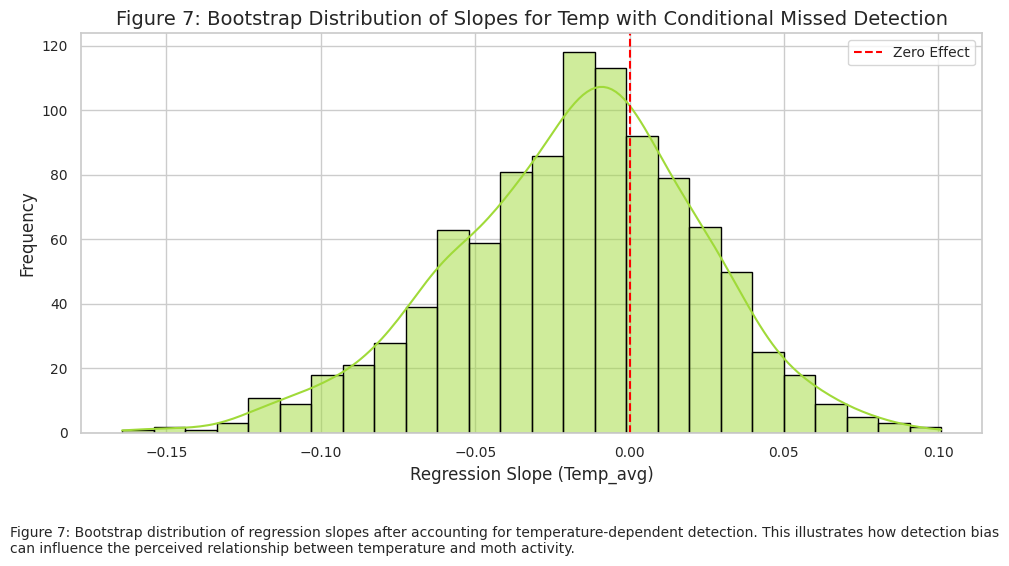

In [100]:
# Monte Carlo simulation: conditional (temperature-dependent) missed detection
n_simulations = 1000

# Detection probability increases with temperature
def get_detection_probability(temp, min_temp_data, max_temp_data):
    normalized_temp = (temp - min_temp_data) / (max_temp_data - min_temp_data)
    detection_prob = 0.1 + 0.8 * normalized_temp
    return np.clip(detection_prob, 0.05, 0.95)

min_temp_data = df['temp_avg'].min()
max_temp_data = df['temp_avg'].max()

# Assume underlying relationship and adjust counts based on detection probability
true_beta_temp = 0.1
true_intercept = 0.5

hypothetical_true_moth_count = true_intercept + true_beta_temp * df['temp_avg']
hypothetical_true_moth_count = np.maximum(0, hypothetical_true_moth_count)

# Simulate observed counts adjusted for conditional detection and run bootstrap regression
boot_slopes_conditional_md = []
for _ in range(n_simulations):
    simulated_observed_moth_counts = []

    for i in range(len(df)):
        current_moth_count = df['moth_count'].iloc[i]
        current_temp_avg = df['temp_avg'].iloc[i]
        detection_prob = get_detection_probability(current_temp_avg, min_temp_data, max_temp_data)

        adjusted_true_count = current_moth_count / detection_prob
        simulated_observed_moth_counts.append(adjusted_true_count)

    temp_sim_df = df.copy()
    temp_sim_df['simulated_true_moth_count'] = simulated_observed_moth_counts

    resampled_sim_df = temp_sim_df.sample(n=len(temp_sim_df), replace=True)
    slope_b, _, _, _, _ = linregress(resampled_sim_df['temp_avg'], resampled_sim_df['simulated_true_moth_count'])
    boot_slopes_conditional_md.append(slope_b)

# Calculate confidence interval
lower_bound_slope_cond = np.percentile(boot_slopes_conditional_md, 2.5)
upper_bound_slope_cond = np.percentile(boot_slopes_conditional_md, 97.5)

print(f"\nMonte Carlo (Bootstrap) for moth_count vs. temp_avg with CONDITIONAL Missed Detection (Temperature-Dependent):")
print(f"  Mean Slope (adjusted for conditional detection): {np.mean(boot_slopes_conditional_md):.4f} (95% CI: [{lower_bound_slope_cond:.4f}, {upper_bound_slope_cond:.4f}])")

# Plot distribution of slopes
plt.figure(figsize=(10, 6))
sns.histplot(boot_slopes_conditional_md, kde=True, color=sns.color_palette('viridis')[5], edgecolor='black') # Using a different color from viridis palette
plt.axvline(x=0, color='red', linestyle='--', label='Zero Effect')
plt.title('Figure 7: Bootstrap Distribution of Slopes for Temp with Conditional Missed Detection', fontsize=14)
plt.xlabel('Regression Slope (Temp_avg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

caption_text_7 = "Figure 7: Bootstrap distribution of regression slopes after accounting for temperature-dependent detection. This illustrates how detection bias can influence the perceived relationship between temperature and moth activity."
plt.figtext(0.01, 0.01, caption_text_7, ha='left', va='bottom', fontsize=10, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

These simulations demonstrate that detection processes can substantially influence observed relationships. Even when a true ecological relationship exists, it may be weakened or obscured by imperfect or variable detection. This highlights a key limitation of transect-based surveys and emphasises the importance of explicitly accounting for detection uncertainty in ecological analyses.

The absence of strong or statistically significant relationships between environmental variables and moth count does not indicate that environmental conditions are unimportant. Instead, it highlights the complexity of ecological systems and the limitations of observational survey data. Golden Sun Moth activity is known to depend on specific environmental thresholds (e.g. sufficient warmth and low wind), but these relationships are often non-linear and may not be captured by simple linear models.
Furthermore, the high variability observed in moth counts across similar environmental conditions suggests that additional unmeasured factors, such as microhabitat conditions, population density, or recent emergence events, likely play a significant role. This reinforces the idea that transect surveys measure observed activity, rather than true abundance.

## **Synthesised Findings and Conclusion**

This project investigated how environmental conditions influence observed Golden Sun Moth activity during transect surveys, while explicitly accounting for uncertainty in real-world ecological data. A multi-faceted approach combining exploratory data analysis, regression modelling, and uncertainty analysis (bootstrapping and Monte Carlo simulations) was used to identify patterns and assess how reliable those patterns are.

## **Key Findings**

1.  **Weak relationships across environmental variables**:
    *   Exploratory analysis and correlation results (**Figure 1**, **Table 1**, **Figure 2**) showed generally weak relationships between moth count and environmental variables. Small positive correlations were observed for temperature (0.096) and wind speed (0.154), while cloud cover and insect richness showed little to no relationship.

    *   Lagged temperature variables also showed very low correlations with moth count (**Figure 5**), indicating that recent temperature conditions (1–3 days prior) did not strongly influence observed activity in this dataset.


2.  **Lagged temperature effects are not supported**:
    *   Regression analyses for lagged temperature variables confirmed these patterns. Linear regression results showed extremely low R² values and non-significant p-values (**Table 3**), while bootstrap confidence intervals consistently included zero (**Table 4**).

    *   Negative Binomial regression, which is more appropriate for count data, produced similar results, with non-significant coefficients and very low explanatory power (**Tables 5** and **6**).

    *   Together, these findings suggest that prior temperature conditions, when considered in isolation, do not have a strong linear effect on observed moth activity.


3.  **High uncertainty in estimated relationships**:
    *   Bootstrap analysis (**Figure 4**) showed that regression coefficients varied widely, with most confidence intervals including zero. This indicates that the estimated relationships are highly sensitive to sampling variability and are not statistically robust.

    *   The grouped hour analysis (**Figure 3**) showed some small fluctuations in moth activity throughout the day, but these patterns were inconsistent and did not indicate a strong temporal effect within the survey window.

4. **Detection processes strongly influence results**:
    *   Monte Carlo simulations (**Figures 6** and **7**) demonstrated that imperfect detection can substantially influence observed relationships.
        *   Under a constant 20% missed detection rate, the temperature effect remained statistically non-significant, with confidence intervals still including zero.
        *   Under temperature-dependent detection, the relationship became even more uncertain, with the potential to completely mask or distort any underlying effect.
    *   This highlights that even if a real ecological relationship exists, it may not be detectable in observational data due to biases in detection.


## **Ecological Interpretation**
The absence of strong statistical relationships does not mean environmental factors are unimportant. Instead, it reflects both ecological complexity and the limitations of observational data.

Golden Sun Moth activity is likely influenced by multiple interacting factors — including temperature, solar radiation, wind, and habitat conditions — which may operate in non-linear ways. In addition, observed moth counts reflect both true abundance and detectability, meaning they are an imperfect measure of population size.

These results highlight the challenge of separating real ecological patterns from observational noise in field-based studies.


## **Limitations**

This study is limited by:

* imperfect detection
* observer variability
* missing and inferred data
* small sample size
* lack of controlled conditions

These factors increase uncertainty and reduce the ability to detect clear relationships. As this is an observational dataset, causal relationships cannot be determined


## **Future Directions**

Future work could improve this analysis by:

* collecting larger and more consistent datasets
* sampling across a wider range of environmental conditions
* including additional variables (e.g. humidity, solar radiation/UV, habitat structure)
* improving detection methods to reduce observational bias
* using models that account for spatial and temporal structure

## **Reflection on Working with Real-World Data**
Working with this dataset highlighted the inherent complexity of ecological field data. Cleaning and transforming the data required assumptions and approximations, each introducing additional uncertainty.

This emphasised the importance of explicitly accounting for uncertainty during analysis. Techniques such as bootstrapping and Monte Carlo simulation were particularly valuable in showing how variable and sensitive the results are.

Overall, this experience reinforced that interpreting ecological data is not just about identifying patterns, but also about understanding how reliable those patterns are.

# **Conclusion**
Although strong statistical relationships were not identified, the findings remain informative. They show that single environmental variables are unlikely to fully explain observed moth activity and highlight the importance of considering uncertainty in ecological analysis.

For conservation monitoring, this suggests that survey design should incorporate multiple environmental variables, improve consistency in data collection, and account for detection bias.

More broadly, this project demonstrates that in ecological research, understanding uncertainty and limitations is just as important as identifying clear statistical relationships.

# **Acknowledgements**
I would like to thank Maisie Walker Stelling, a PhD candidate at the Fenner School of Environment & Society, for the opportunity to assist with field data collection over the summer. Her research on Golden Sun Moth translocation and population growth gave valuable context to this work, and it was rewarding to see this project develop from that experience.

I would also like to thank David Heslop for his guidance throughout the course. While I found the course challenging, I found it highly engaging and valuable, particularly in developing my approach to data analysis and uncertainty. This project has strengthened my interest in data-driven ecological research, and I am keen to continue developing my coding and analytical skills in future work.

# **Personal Reflection**
This project was motivated by my interest in applied ecology and my experience working with real-world environmental datasets. The Golden Sun Moth is a critically endangered species with highly specific activity requirements, making it an ideal case study for exploring how environmental conditions influence observed ecological patterns. I was particularly interested in understanding not only whether environmental variables affect moth activity, but also how uncertainty in field data shapes these relationships.

A particularly rewarding aspect of this project was engaging with the full lifecycle of the data. I was involved in field collection, followed by data cleaning, analysis, and interpretation. Participating in fieldwork created a strong connection to the dataset and made the analytical process more meaningful. I also really valued the opportunity to spend time over the summer volunteering with my friend on her PhD field data collection, and it has been especially rewarding to see this project come directly out of that experience. Despite some results being weaker or less conclusive than expected, it was satisfying to carry the data through to final outputs. This experience reinforced the value of ecological monitoring and grounded the analysis in real-world observations rather than abstract data.

One of the main challenges was the complexity and “messiness” of the dataset. Although initial cleaning had been completed, further decisions were required during analysis, including handling missing values and interpreting subjective variables such as cloud cover and wind categories. Inconsistent sampling conditions also introduced variability. These challenges highlighted that working with ecological data requires ongoing judgement and careful assumptions, which must be considered to reduce bias.

Another key challenge was that many statistical analyses produced weak or non-significant results. I initially expected temperature to strongly influence moth activity, given its known importance for insects. However, correlations were low and confidence intervals overlapped zero. While this was somewhat disappointing, it became an important learning experience. It reinforced that meaningful scientific outcomes are not always defined by strong or expected results, and that weak or uncertain findings can still be valuable.

In response, I shifted my focus toward interpretation and uncertainty, incorporating bootstrapping and Monte Carlo simulations. These approaches helped explore how detection bias and sampling variability influence observed patterns. In particular, modelling imperfect detection demonstrated how underlying ecological relationships may be obscured by observational processes, which is a key challenge in field studies.

This project has also shaped how I will approach future field data collection. It became clear that recording a broader range of environmental variables could improve the ability to detect meaningful patterns, including factors such as solar radiation, humidity, and more detailed wind measurements. Greater consistency in survey conditions and increased sampling frequency would also help reduce variability and strengthen future analyses.

Overall, this project strengthened my ability to work with complex ecological datasets and deepened my understanding of uncertainty in data analysis. It also reinforced the importance of critical thinking, persistence, and transparency when interpreting real-world data.

***A selection of photographs from the fieldwork associated with this project is provided below.***

## **Below are some photos from the field work collecting the data analysed in this notebook:**

### **Image 1: Male GSM on ground** - note darker colours

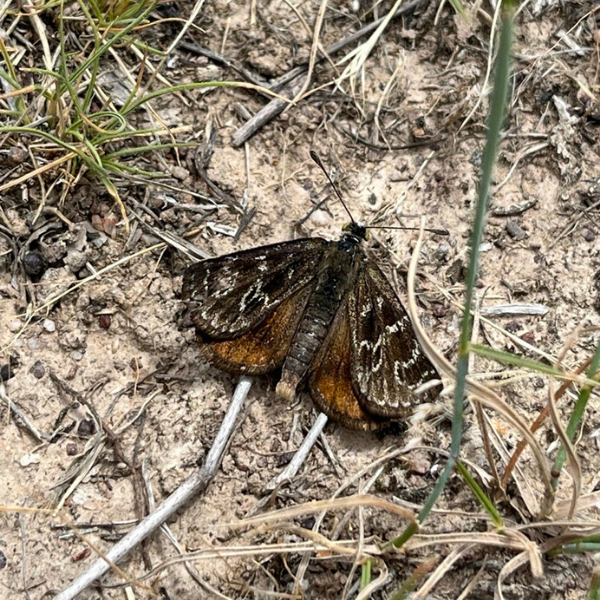

### **Image 2: Female GSM** - this was a female we trapped while doing transects, with the goal to study if captive breeding is possible for GSMs. Note golden orange wings.

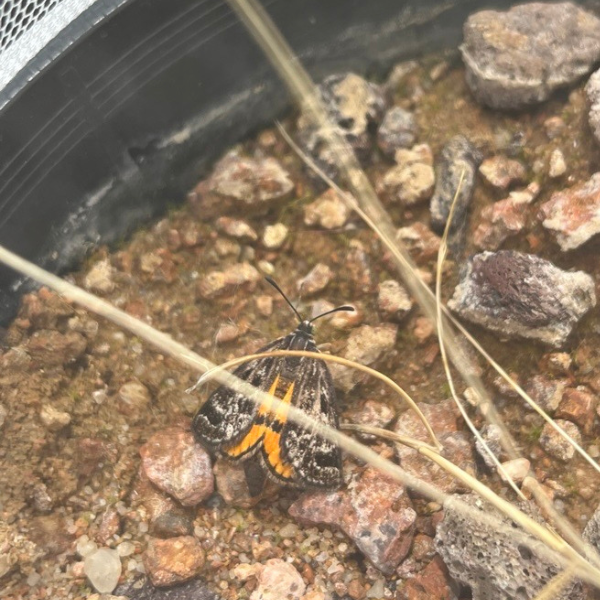

### **Image 3: One of the many grassland study sites (camera monitors pictured)**

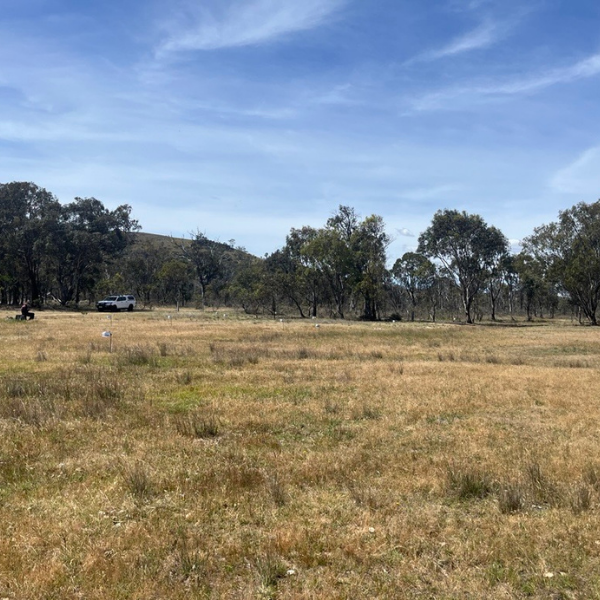